In [1]:
''' 0) SETUP
 Key design choice:
- We generate adversarial perturbations in pixel space x ∈ [0,1],
   so ε=8/255 and 16/255 have their standard meaning.
- We then apply ImageNet preprocessing (resize + normalize) before model inference.
'''
import torch
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(0)
np.random.seed(0)


In [2]:

''' 1) DESCRIPTION OF VICTIM MODEL(S)

1.1 Model architecture and source (pretrained weights used)
 - Source model (victim): ResNet-18, ImageNet pretrained weights
 - Target model (transferability): VGG-16, ImageNet pretrained weights

 1.2 Original accuracy on clean test data
 Clean baseline is reported below using the victim model’s behavior on clean inputs:
 - mean top-1 confidence
 - self-consistency (prediction stability)

 1.3 Preprocessing applied to inputs
 - Resize to 224×224
 - Normalize with ImageNet mean/std
 - Attacks operate in pixel space [0,1]; preprocessing is applied after perturbation.'''

# Data (CIFAR-10 as inputs)
BATCH_SIZE = 32
NUM_WORKERS = 2

cifar_transform = T.Compose([T.ToTensor()])  # -> x in [0,1]
testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=cifar_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Victim models
source_weights = models.ResNet18_Weights.DEFAULT
target_weights = models.VGG16_Weights.DEFAULT

source_model = models.resnet18(weights=source_weights).eval().to(device)
target_model = models.vgg16(weights=target_weights).eval().to(device)

imagenet_classes = source_weights.meta["categories"]

# Preprocessing
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
resize_224 = T.Resize((224, 224), antialias=True)

def preprocess_for_model(x01: torch.Tensor) -> torch.Tensor:
    # x01: [B,3,H,W] in [0,1]
    x = resize_224(x01)
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return x

@torch.no_grad()
def predict_top1(model, x01: torch.Tensor):
    logits = model(preprocess_for_model(x01))
    probs = torch.softmax(logits, dim=1)
    top1_prob, top1_idx = probs.max(dim=1)
    return top1_idx, top1_prob, probs

def clean_metrics(model, dataloader, max_batches=50):
    total, stable = 0, 0
    confs = []
    for i, (x, _) in enumerate(dataloader):
        if i >= max_batches:
            break
        x = x.to(device)
        idx1, p1, _ = predict_top1(model, x)
        idx2, _, _ = predict_top1(model, x)
        stable += (idx1 == idx2).sum().item()
        total += x.size(0)
        confs.append(p1.detach().cpu().numpy())
    return {
        "self_consistency": stable/total if total else 0.0,
        "mean_top1_conf": float(np.concatenate(confs).mean()) if confs else 0.0,
        "n": total
    }

print("Source clean metrics:", clean_metrics(source_model, testloader))
print("Target clean metrics:", clean_metrics(target_model, testloader))


100%|██████████| 170M/170M [00:03<00:00, 48.8MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 122MB/s]


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 189MB/s]


Source clean metrics: {'self_consistency': 1.0, 'mean_top1_conf': 0.39092060923576355, 'n': 1600}
Target clean metrics: {'self_consistency': 1.0, 'mean_top1_conf': 0.32702869176864624, 'n': 1600}


In [3]:
'''2) FGSM IMPLEMENTATION
Mathematical formulation (untargeted, L∞):
x_adv = clip_[0,1]( x + ε * sign( ∇_x J(θ, preprocess(x), y) ) )
Attack label y:
- Set y to the model's clean prediction (self-label) so we can measure flip rate.'''

def fgsm_attack(model, x01, y, epsilon):
    model.eval()
    x = x01.clone().detach().to(device)
    y = y.clone().detach().to(device)
    x.requires_grad = True

    logits = model(preprocess_for_model(x))
    loss = F.cross_entropy(logits, y)

    model.zero_grad(set_to_none=True)
    loss.backward()

    grad_sign = x.grad.detach().sign()
    x_adv = torch.clamp(x + epsilon * grad_sign, 0.0, 1.0)
    return x_adv.detach()


In [4]:

'''3) PGD IMPLEMENTATION
PGD (Madry-style) L∞:
Initialize (random start):
   x0 = clip_[0,1]( x + Uniform(-ε, +ε) )
 Iterate:
   x_{t+1} = clip_[0,1]( x + clip_[-ε,+ε](x_t + α*sign(∇_x J) - x) )

 PGD extends FGSM by performing multiple iterative gradient steps to more effectively maximize the loss under an L∞ constraint.'''

def pgd_attack(model, x01, y, epsilon, alpha, iters, random_start=True):
    model.eval()
    x = x01.clone().detach().to(device)
    y = y.clone().detach().to(device)

    if random_start:
        x_adv = torch.clamp(x + torch.empty_like(x).uniform_(-epsilon, epsilon), 0.0, 1.0)
    else:
        x_adv = x.clone().detach()

    for _ in range(iters):
        x_adv.requires_grad = True
        logits = model(preprocess_for_model(x_adv))
        loss = F.cross_entropy(logits, y)

        model.zero_grad(set_to_none=True)
        loss.backward()

        x_adv = x_adv + alpha * x_adv.grad.detach().sign()
        eta = torch.clamp(x_adv - x, -epsilon, epsilon)
        x_adv = torch.clamp(x + eta, 0.0, 1.0).detach()

    return x_adv


In [5]:

'''4) EXPERIMENTS (SUCCESS RATES + CONFIDENCE DROP)
Attack success definition (untargeted, self-labeled):
 - y_clean := model(x_clean) top-1 label
 - success if model(x_adv) != y_clean

 mean confidence drop for y_clean:
   mean( P(y_clean|x_clean) - P(y_clean|x_adv) )'''

@torch.no_grad()
def batch_conf_for_label(model, x01, y_label):
    logits = model(preprocess_for_model(x01))
    probs = torch.softmax(logits, dim=1)
    return probs.gather(1, y_label.view(-1,1)).squeeze(1)

def eval_attack(model, dataloader, attack_fn, attack_kwargs, max_batches=10):
    total, flips = 0, 0
    conf_drop = []
    for i, (x, _) in enumerate(dataloader):
        if i >= max_batches:
            break
        x = x.to(device)
        y_clean, _, _ = predict_top1(model, x)
        p_clean = batch_conf_for_label(model, x, y_clean)

        x_adv = attack_fn(model, x, y_clean, **attack_kwargs)

        y_adv, _, _ = predict_top1(model, x_adv)
        p_adv = batch_conf_for_label(model, x_adv, y_clean)

        flips += (y_adv != y_clean).sum().item()
        total += x.size(0)
        conf_drop.append((p_clean - p_adv).detach().cpu().numpy())

    return {
        "success_rate": flips/total if total else 0.0,
        "mean_conf_drop": float(np.concatenate(conf_drop).mean()) if conf_drop else 0.0,
        "n": total
    }

epsilons = [8/255, 16/255]
rows = []

# FGSM + PGD at both eps
for eps in epsilons:
    rows.append({"attack":"FGSM", "epsilon":eps, **eval_attack(source_model, testloader, fgsm_attack, {"epsilon": eps})})
    rows.append({"attack":"PGD-10", "epsilon":eps, **eval_attack(source_model, testloader, pgd_attack,
                                                                  {"epsilon": eps, "alpha": eps/4, "iters": 10, "random_start": True})})

df_main = pd.DataFrame(rows)
df_main["epsilon"] = df_main["epsilon"].map(lambda x: f"{x:.5f} ({x*255:.0f}/255)")
print("FGSM/PGD results (source model):")
display(df_main)

# PGD iteration study at eps=8/255
iters_list = [1, 3, 5, 10, 20]
eps = 8/255
rows_it = []
for iters in iters_list:
    rows_it.append({"attack":f"PGD-{iters}", "iters":iters, "epsilon":f"{eps:.5f} (8/255)",
                    **eval_attack(source_model, testloader, pgd_attack,
                                  {"epsilon": eps, "alpha": eps/4, "iters": iters, "random_start": True})})

df_iters = pd.DataFrame(rows_it)
print("PGD iterations study (source model, eps=8/255):")
display(df_iters)


FGSM/PGD results (source model):


,attack,epsilon,success_rate,mean_conf_drop,n
0,FGSM,0.03137 (8/255),1.0,0.373509,320
1,PGD-10,0.03137 (8/255),1.0,0.374832,320
2,FGSM,0.06275 (16/255),1.0,0.372340,320
3,PGD-10,0.06275 (16/255),1.0,0.374832,320


PGD iterations study (source model, eps=8/255):


,attack,iters,epsilon,success_rate,mean_conf_drop,n
0,PGD-1,1,0.03137 (8/255),1.0,0.373937,320
1,PGD-3,3,0.03137 (8/255),1.0,0.374831,320
2,PGD-5,5,0.03137 (8/255),1.0,0.374832,320
3,PGD-10,10,0.03137 (8/255),1.0,0.374832,320
4,PGD-20,20,0.03137 (8/255),1.0,0.374832,320


In [7]:

'''5) TRANSFERABILITY EXPERIMENTS
Source model: ResNet-18 (ImageNet pretrained)
 Target model: VGG-16 (ImageNet pretrained)

 Transfer success rate definition (practical for mismatched labels):
 - Compare target's prediction on clean vs adversarial:
     success_transfer = [ target(x_adv) != target(x_clean) ]
 This measures whether adversarial examples crafted on the source
 also flip the target's decision.'''

def eval_transfer(source_model, target_model, dataloader, attack_fn, attack_kwargs, max_batches=10):
    total, src_flips, tgt_flips = 0, 0, 0
    for i, (x, _) in enumerate(dataloader):
        if i >= max_batches:
            break
        x = x.to(device)

        y_src_clean, _, _ = predict_top1(source_model, x)
        y_tgt_clean, _, _ = predict_top1(target_model, x)

        x_adv = attack_fn(source_model, x, y_src_clean, **attack_kwargs)

        y_src_adv, _, _ = predict_top1(source_model, x_adv)
        y_tgt_adv, _, _ = predict_top1(target_model, x_adv)

        src_flips += (y_src_adv != y_src_clean).sum().item()
        tgt_flips += (y_tgt_adv != y_tgt_clean).sum().item()
        total += x.size(0)

    return {"source_success_rate": src_flips/total if total else 0.0,
            "transfer_success_rate": tgt_flips/total if total else 0.0,
            "n": total}

rows_tr = []
for eps in epsilons:
    rows_tr.append({"attack":"FGSM", "epsilon":eps, **eval_transfer(source_model, target_model, testloader, fgsm_attack, {"epsilon": eps})})
    rows_tr.append({"attack":"PGD-10", "epsilon":eps, **eval_transfer(source_model, target_model, testloader, pgd_attack,
                                                                      {"epsilon": eps, "alpha": eps/4, "iters": 10, "random_start": True})})

df_tr = pd.DataFrame(rows_tr)
df_tr["epsilon"] = df_tr["epsilon"].map(lambda x: f"{x:.5f} ({x*255:.0f}/255)")
print("Transferability (source->target):")
display(df_tr)

''' Discussion (why transfer does/doesn't work):
- Transferability happens because different architectures can learn similar decision boundaries / features.
- Transfer rates are usually lower than white-box success because boundaries are not identical across models. '''


Transferability (source->target):


,attack,epsilon,source_success_rate,transfer_success_rate,n
0,FGSM,0.03137 (8/255),1.0,0.868750,320
1,PGD-10,0.03137 (8/255),1.0,0.859375,320
2,FGSM,0.06275 (16/255),1.0,0.962500,320
3,PGD-10,0.06275 (16/255),1.0,0.971875,320


" Discussion (why transfer does/doesn't work):\n- Transferability happens because different architectures can learn similar decision boundaries / features.\n- Transfer rates are usually lower than white-box success because boundaries are not identical across models. "

Gallery examples collected: 10


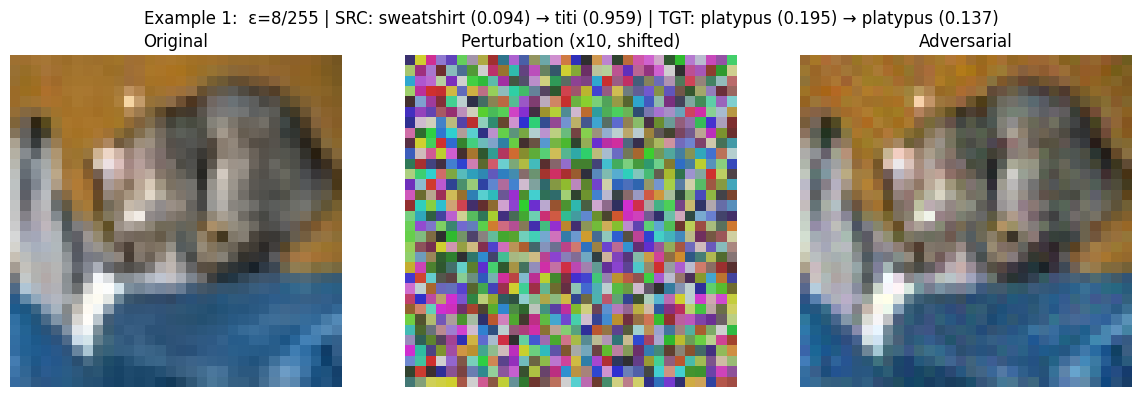

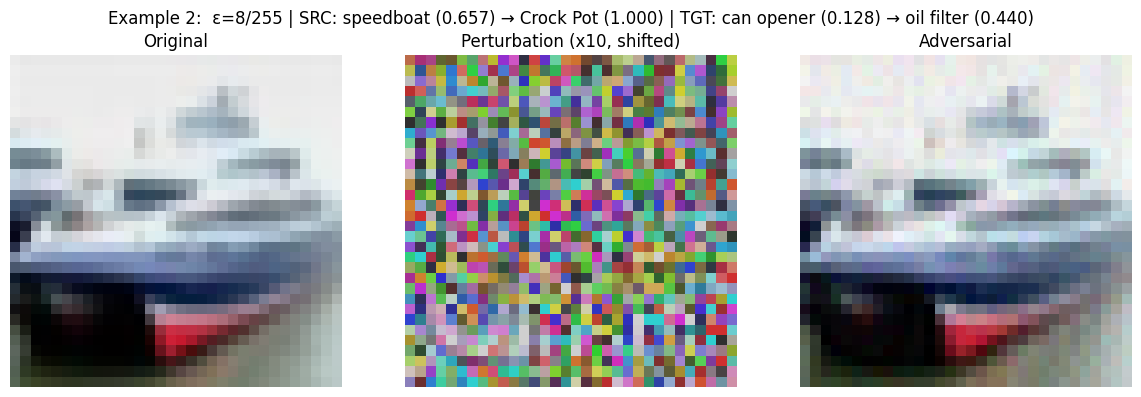

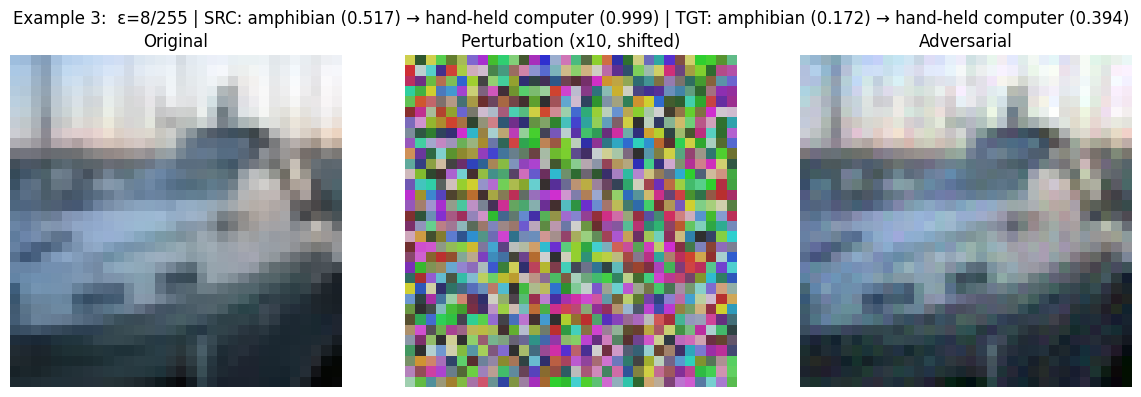

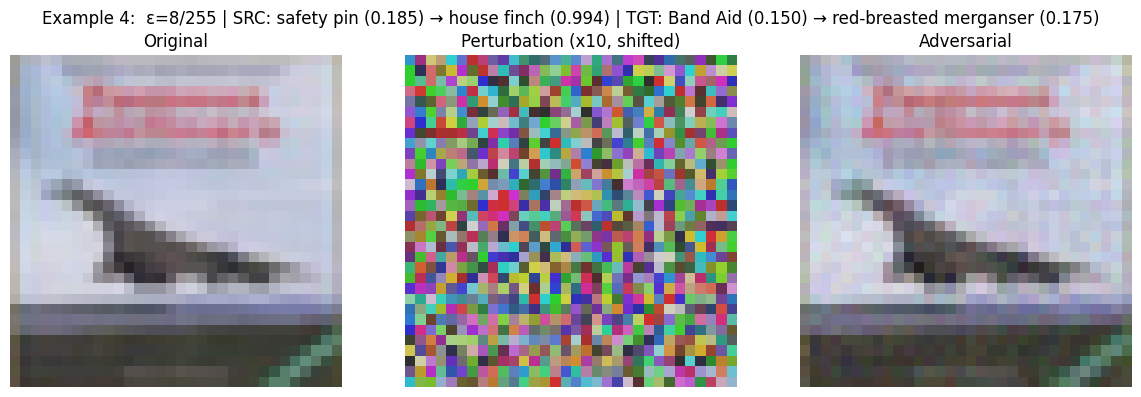

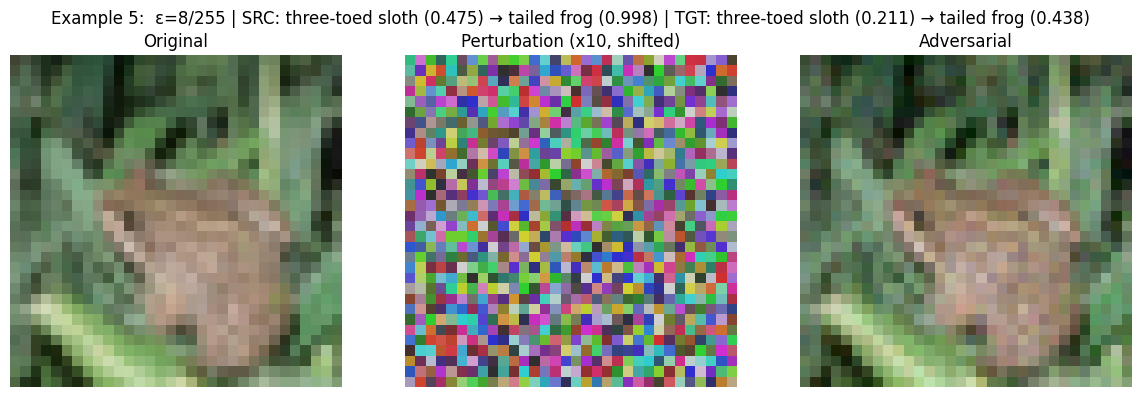

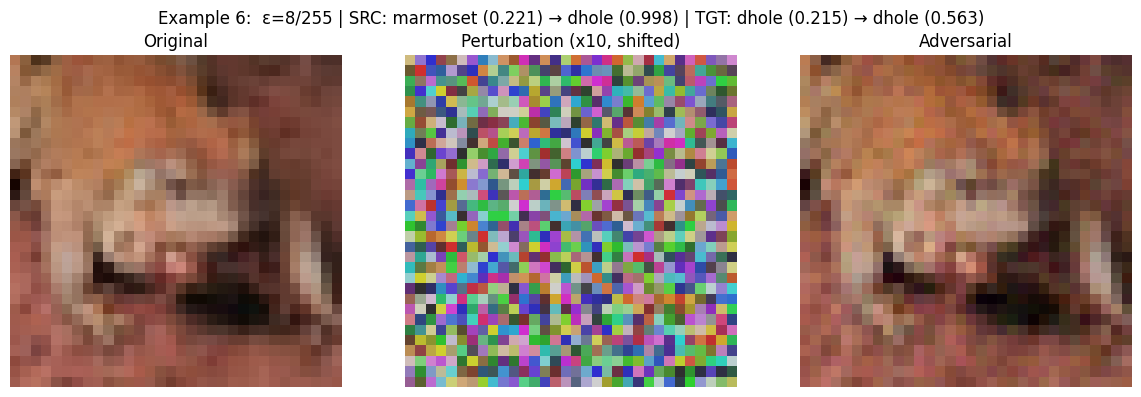

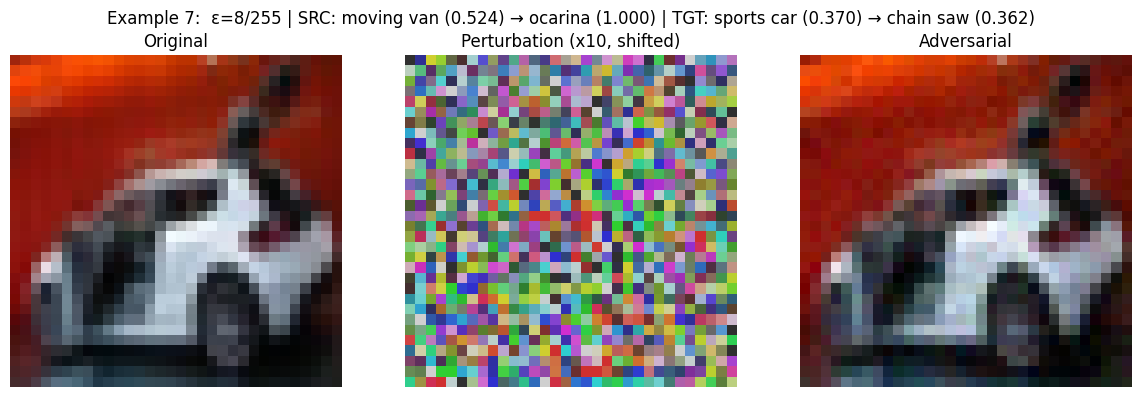

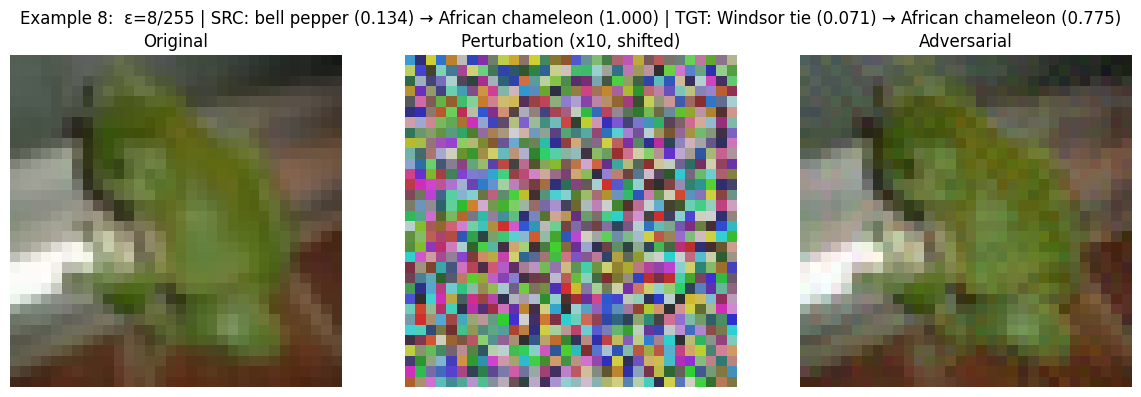

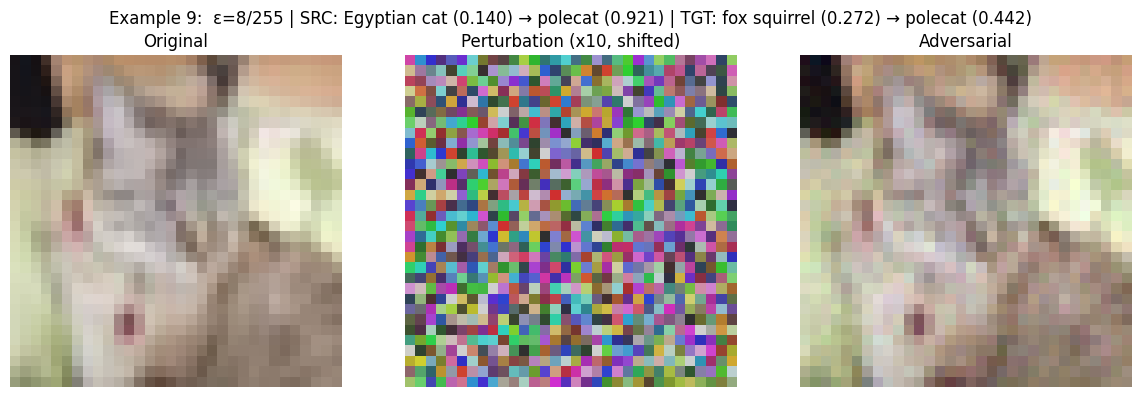

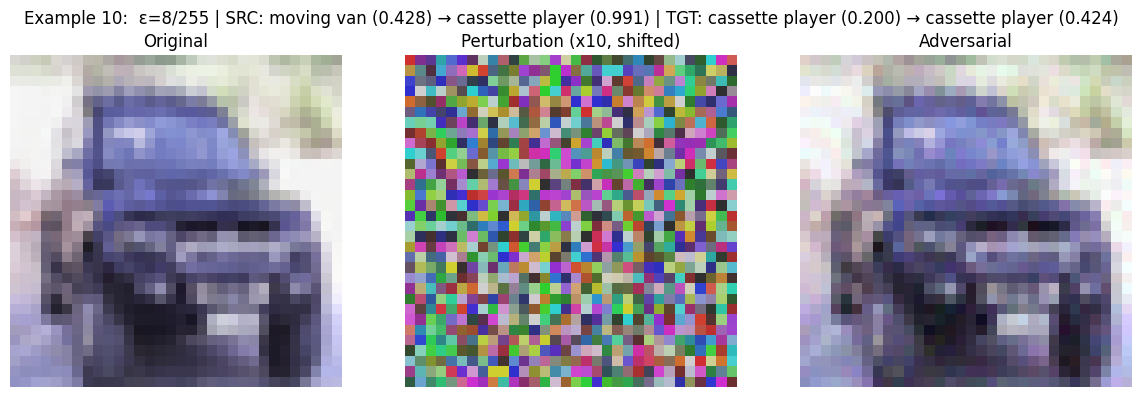

In [8]:

''' 6) VISUALIZATION GALLERY (≥10 EXAMPLES)
Created a gallery of 10 successful adversarial examples (on source),
and display both source + target labels/confidences for clean vs adversarial.'''

@torch.no_grad()
def top1_label_and_conf(model, x01):
    idx, p, _ = predict_top1(model, x01)
    return idx.item(), p.item()

def show_triplet(x_clean, x_adv, eps, title_prefix=""):
    x_clean_b = x_clean.unsqueeze(0).to(device)
    x_adv_b = x_adv.unsqueeze(0).to(device)

    src_idx_c, src_p_c = top1_label_and_conf(source_model, x_clean_b)
    src_idx_a, src_p_a = top1_label_and_conf(source_model, x_adv_b)

    tgt_idx_c, tgt_p_c = top1_label_and_conf(target_model, x_clean_b)
    tgt_idx_a, tgt_p_a = top1_label_and_conf(target_model, x_adv_b)

    delta = (x_adv - x_clean).cpu()
    delta_vis = torch.clamp(delta * 10.0 + 0.5, 0.0, 1.0)  # amplify + shift for visibility

    plt.figure(figsize=(12,4))
    ax1 = plt.subplot(1,3,1)
    ax2 = plt.subplot(1,3,2)
    ax3 = plt.subplot(1,3,3)

    ax1.imshow(torch.clamp(x_clean, 0, 1).permute(1,2,0))
    ax1.set_title("Original")
    ax1.axis("off")

    ax2.imshow(delta_vis.permute(1,2,0))
    ax2.set_title("Perturbation (x10, shifted)")
    ax2.axis("off")

    ax3.imshow(torch.clamp(x_adv, 0, 1).permute(1,2,0))
    ax3.set_title("Adversarial")
    ax3.axis("off")

    plt.suptitle(
        f"{title_prefix} ε={eps*255:.0f}/255 | "
        f"SRC: {imagenet_classes[src_idx_c]} ({src_p_c:.3f}) → {imagenet_classes[src_idx_a]} ({src_p_a:.3f}) | "
        f"TGT: {imagenet_classes[tgt_idx_c]} ({tgt_p_c:.3f}) → {imagenet_classes[tgt_idx_a]} ({tgt_p_a:.3f})"
    )
    plt.tight_layout()
    plt.show()

def collect_success_examples(attack_fn, attack_kwargs, num_examples=10, max_batches=200):
    examples = []
    for i, (x, _) in enumerate(testloader):
        if i >= max_batches:
            break
        x = x.to(device)
        y_clean, _, _ = predict_top1(source_model, x)
        x_adv = attack_fn(source_model, x, y_clean, **attack_kwargs)
        y_adv, _, _ = predict_top1(source_model, x_adv)
        flips = (y_adv != y_clean).detach().cpu().numpy()
        for j in range(x.size(0)):
            if flips[j]:
                examples.append((x[j].detach().cpu(), x_adv[j].detach().cpu()))
                if len(examples) >= num_examples:
                    return examples
    return examples

# Gallery setting (strong baseline): PGD-10, eps=8/255
gallery_eps = 8/255
gallery_examples = collect_success_examples(
    pgd_attack, {"epsilon": gallery_eps, "alpha": gallery_eps/4, "iters": 10, "random_start": True},
    num_examples=10
)
print("Gallery examples collected:", len(gallery_examples))

for k, (xc, xa) in enumerate(gallery_examples):
    show_triplet(xc, xa, gallery_eps, title_prefix=f"Example {k+1}: ")


In [ ]:

'''7) BRIEF DISCUSSION / ANALYSIS (COMMENTS ONLY)

 Patterns observed in successful perturbations:
 - Often look like high-frequency noise spread across the image.
 - Small L∞-bounded changes can cause large prediction changes due to
   high-dimensional sensitivity / reliance on non-robust features.

 Budget vs perceptibility:
 - Increasing ε from 8/255 to 16/255 generally increases success rate.
 - ε=8/255 is typically hard to notice; ε=16/255 may become slightly visible.
 - Model confidence tends to drop sharply even when changes are subtle.
 What defenses might be effective:
 - Adversarial training (PGD-based) is the strongest standard empirical defense.
 - Certified defenses can provide provable robustness but often trade off accuracy/compute.
 - Simple preprocessing (JPEG/blur) can be bypassed by adaptive attacks.'''

